# Graph 4: Movie Runtime Over Time

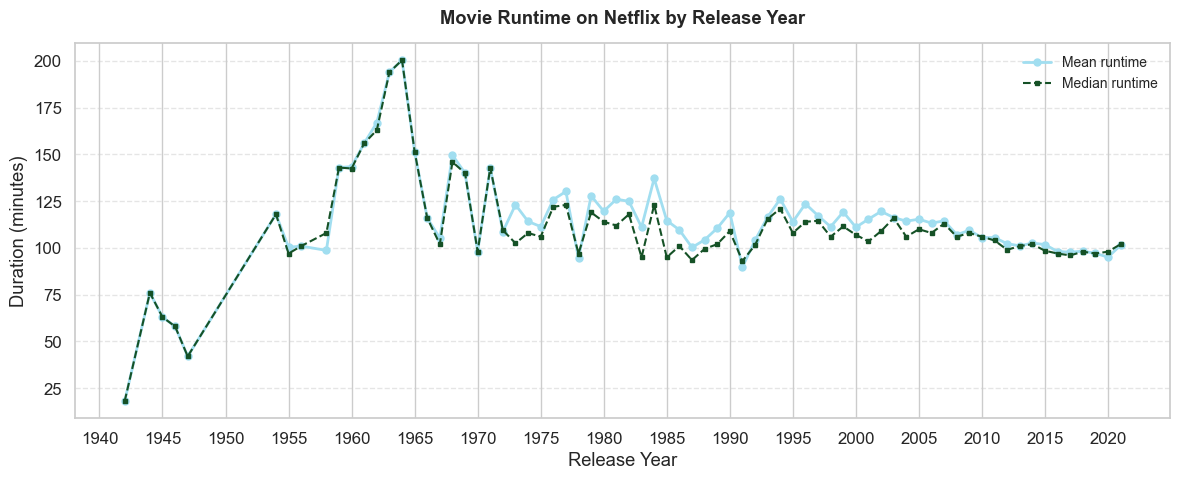

Saved → graph4_movie_runtime.png


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

df = pd.read_csv("netflix_titles_clean.csv")

# Use all movie data
movies = df[
    (df["type"] == "Movie") &
    (df["duration_value"].notna())
].copy()

year_min = int(movies["release_year"].min())
year_max = int(movies["release_year"].max())

stats = (
    movies.groupby("release_year")["duration_value"]
    .agg(["mean", "median", "std", "count"])
    .reset_index()
)
stats.columns = ["year", "mean", "median", "std", "count"]

MEAN_COLOR   = "#A1DEF0"
MEDIAN_COLOR = "#155126"

sns.set_theme(style="whitegrid", font_scale=1.1)
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    stats["year"], stats["mean"],
    color=MEAN_COLOR, linewidth=2, marker="o", markersize=5, label="Mean runtime"
)
ax.plot(
    stats["year"], stats["median"],
    color=MEDIAN_COLOR, linewidth=1.5, linestyle="--", marker="s", markersize=3, label="Median runtime"
)

ax.set_title(
    f"Movie Runtime on Netflix by Release Year", fontweight="bold", pad=14
)
ax.set_xlabel("Release Year")
ax.set_ylabel("Duration (minutes)")
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.legend(fontsize=10, frameon=False)

plt.tight_layout()
plt.savefig("graph4_movie_runtime.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved \u2192 graph4_movie_runtime.png")
